###   Крутки

In [11]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import time


%matplotlib inline

In [12]:
#  Число экспериментов
n_exp = 50000

Warranty_hero_1 = 75
Warranty_hero_2 = 90

base_hero_prob = 0.006
base_weapon_prob = 0.0075

Warranty_weapon_1 = 65
Warranty_weapon_2 = 80

after_increase_hero_prob = 0.3238 # c 75
after_increase_weapon_prob = 0.2457 # c 65

In [13]:
def generate_hero_prob_arr():
    arr = []
    sum_prob = 0
    for roll in range(1, 76):
        sum_prob += base_hero_prob*(1-sum_prob)
        arr.append(sum_prob)

    for roll in range(76, 90):
        sum_prob += after_increase_hero_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)

# генерация массива с заданной крутки
def generate_hero_prob_arr_from(start):
    start+=1
    arr = []
    sum_prob = 0
    if start < 76:
        for roll in range(start, 76):
            sum_prob += base_hero_prob*(1-sum_prob)
            arr.append(sum_prob)
        start = 76

    for roll in range(start, 90):
        sum_prob += after_increase_hero_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)
    
def generate_weapon_prob_arr():
    arr = []
    sum_prob = 0
    for roll in range(1, 66):
        sum_prob += base_weapon_prob*(1-sum_prob)
        arr.append(sum_prob)

    for roll in range(66, 80):
        sum_prob += after_increase_weapon_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)

# генерация массива с заданной крутки
def generate_weapon_prob_arr_from(start):
    start+=1
    arr = []
    sum_prob = 0
    if start < 66:
        for roll in range(start, 66):
            sum_prob += base_weapon_prob*(1-sum_prob)
            arr.append(sum_prob)
        start = 66

    for roll in range(start, 80):
        sum_prob += after_increase_weapon_prob*(1-sum_prob)
        arr.append(sum_prob)
    arr.append(1)
    return np.array(arr)

def find_index(arr, prob):
    return np.searchsorted(arr, prob, side="right") + 1
    for i in range(len(arr)):
        if arr[i] > prob:
            return i + 1
    return len(arr)

def find_index_fast(arr, prob):
    return np.searchsorted(arr, prob, side="right") + 1
    
hero_prob_arr = generate_hero_prob_arr()
weapon_prob_arr = generate_weapon_prob_arr()
# семплы для моделирования всех 50/50, 75/25 и 37.5/37.5%/25%.
weapon_sample = [0, 0, 1, 1, 1, 2, 2, 2]
hero_sample_base = [0, 1]
hero_sample_2_lose = [0, 1, 1, 1]
hero_sample_3_lose = [1]

# 70 + find_index(generate_hero_prob_arr_from(70), 0.4)
# [a_i - b_i for a_i, b_i in zip(hero_prob_arr, hero_prob_arr2)]

### 1 эксперимент подсчета круток на ивентового 5* героя

In [14]:
def get_event_hero_exp_from(hero_prob_arr_from, hard_warranty, sample):
    roll = find_index(hero_prob_arr_from, random.random())
    if hard_warranty:
        return roll, False
    if random.choice(sample) == 0:
        return roll + find_index(hero_prob_arr, random.random()), False
    return roll, True

# до обновления
def get_event_hero_exp_48():
    roll = find_index(hero_prob_arr, random.random())
    if random.getrandbits(1):
        return roll
    return roll + find_index(hero_prob_arr, random.random())

# после обновления
def get_event_hero_exp_50(sample):
    roll = find_index(hero_prob_arr, random.random())
    if random.choice(sample) == 0:
        return roll + find_index(hero_prob_arr, random.random()), False
    return roll, True

### 1 эксперимент подсчета круток на ивентового 5* героя с констами

In [15]:
def get_event_hero(hero_prob_arr_from, hard_warranty = False, count = 1, lose_srtick = 0):
    if count == 0:
        return 0
    roll = 0
    new_roll = 0
    is_won = False
    
    if lose_srtick < 2:
         roll, is_won = get_event_hero_exp_from(hero_prob_arr_from, hard_warranty, hero_sample_base)
    elif lose_srtick == 2:
         roll, is_won = get_event_hero_exp_from(hero_prob_arr_from, hard_warranty, hero_sample_2_lose)
    else:
         roll, is_won = get_event_hero_exp_from(hero_prob_arr_from, hard_warranty, hero_sample_3_lose)

    if is_won:
        lose_srtick = 0
    else:
        lose_srtick += 1
    
    for i in range(1, count):
        if lose_srtick < 2:
            new_roll, is_won = get_event_hero_exp_50(hero_sample_base)
        elif lose_srtick == 2:
             new_roll, is_won = get_event_hero_exp_50(hero_sample_2_lose)
        else:
             new_roll, is_won = get_event_hero_exp_50(hero_sample_3_lose)

        if is_won:
            lose_srtick = 0
        else:
            lose_srtick += 1
        roll += new_roll
    return roll

# до обновления
def get_event_hero_from_zero_48(count):
    roll = 0
    for i in range(0, count):
        roll += get_event_hero_exp_48()
    return roll

# после обновления
def get_event_hero_from_zero_50(count):
    roll = 0
    lose_srtick = 0
    new_roll = 0
    is_won = False
    
    for i in range(0, count):
        if lose_srtick < 2:
            new_roll, is_won = get_event_hero_exp_50(hero_sample_base)
        elif lose_srtick == 2:
             new_roll, is_won = get_event_hero_exp_50(hero_sample_2_lose)
        else:
             new_roll, is_won = get_event_hero_exp_50(hero_sample_3_lose)

        if is_won:
            lose_srtick = 0
        else:
            lose_srtick += 1
        roll += new_roll
    return roll

### 1 эксперимент подсчета круток на ивентового 5* оружия

In [16]:
def get_event_weapon_exp_from(weapon_prob_arr_from):
    roll = find_index(weapon_prob_arr_from, random.random())
    sample = random.choice(weapon_sample)
    if sample == 2:
        return roll
    return roll + find_index(weapon_prob_arr, random.random())

# до обновления
def get_event_weapon_exp_48():
    hard_warranty = False
    stuck_point = 0
    roll = find_index(weapon_prob_arr, random.random())
    
    while stuck_point != 2:
        if hard_warranty:
            if random.getrandbits(1):
                break
            else:
                stuck_point += 1
                hard_warranty = False
        else:
            sample = random.choice(weapon_sample)
            if sample == 0:
                hard_warranty = True
                stuck_point += 1
            elif sample == 1:
                stuck_point += 1
            else:
                break
        roll += find_index(weapon_prob_arr, random.random())
    return roll

# после обновления
def get_event_weapon_exp_50():
    roll = find_index(weapon_prob_arr, random.random())
    sample = random.choice(weapon_sample)
    if sample == 2:
        return roll
    return roll + find_index(weapon_prob_arr, random.random())

### 1 эксперимент подсчета круток на ивентового 5* оружия с констами

In [17]:
def get_event_weapon(weapon_prob_arr_from, count = 1):
    if count == 0:
        return 0
    roll = get_event_weapon_exp_from(weapon_prob_arr_from)
    
    for i in range(1, count):
        roll += get_event_weapon_exp_50()
    return roll

# до обновления
def get_event_weapon_from_zero_48(count):
    roll = 0
    for i in range(0, count):
        roll += get_event_weapon_exp_48()
    return roll

# после обновления
def get_event_weapon_from_zero_50(count):
    roll = 0
    for i in range(0, count):
        roll += get_event_weapon_exp_50()
    return roll

### число роллов для героя и его сигны

In [18]:
def count_roll_for_hero_weapon(hard_warranty_hero = False, roll_completed_hero = 0, count_hero = 0, lose_srtick = 0,
                             roll_completed_weapon = 0, count_weapon = 0):
    res = np.empty(n_exp)
    hero_prob_arr_from = generate_hero_prob_arr_from(roll_completed_hero)
    weapon_prob_arr_from = generate_weapon_prob_arr_from(roll_completed_weapon)
    for i in range(n_exp):
        res[i] = (get_event_hero(hero_prob_arr_from, hard_warranty_hero, count_hero, lose_srtick)
            + get_event_weapon(weapon_prob_arr_from, count_weapon))

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

### число роллов для героя

In [19]:
def count_roll_for_hero(hard_warranty = False, roll_completed = 0, count = 0, lose_srtick = 0):
    res = np.empty(n_exp)
    hero_prob_arr_from = generate_hero_prob_arr_from(roll_completed)
    for i in range(n_exp):
        res[i] = get_event_hero(hero_prob_arr_from, hard_warranty, count, lose_srtick)

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

### Удача аккаунта

In [20]:
def calculate_account_luck(count_hero_before, count_weapon_before, count_hero_after, count_weapon_after, count_chronicled):
    res = np.empty(n_exp)
    for i in range(n_exp):
        res[i] = (get_event_hero_from_zero_48(count_hero_before) + get_event_weapon_from_zero_48(count_weapon_before)
                  + get_event_hero_from_zero_50(count_hero_after) + get_event_weapon_from_zero_50(count_weapon_after)
                  + get_event_hero_from_zero_48(count_chronicled))

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

In [21]:
# main
# before 5.0
# charachters: 51, pulls: 4786
# weapons: 7, pulls: 732
# after 5.0
# charachters: 21
# weapons: 9
# chronicled: 3

start_time = time.time()
q, frame, w = calculate_account_luck(count_hero_before = 51, count_weapon_before = 7, count_hero_after = 21, count_weapon_after = 9, count_chronicled = 3)
sorted = frame.sort_values(by=[0])
end_time = time.time()
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,7982.00
0.200,8161.00
0.400,8407.00
0.500,8511.00
0.550,8560.45
0.600,8614.00
0.650,8667.00
0.700,8724.00
0.750,8789.00
0.800,8855.00


In [22]:
print("--- %s seconds ---" % (end_time - start_time))

--- 12.600862503051758 seconds ---


In [23]:
# main
luck_coef = len(sorted[sorted[0] <= 8277])/50000
print(f"{luck_coef:.4%} людей удачиливее вас")

28.6620% людей удачиливее вас


### Персонаж + Оружие

In [24]:
q, frame, w = count_roll_for_hero_weapon(hard_warranty_hero = False, roll_completed_hero = 3, count_hero = 1, lose_srtick = 0,
                             roll_completed_weapon = 4, count_weapon = 1)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99])

,0
0.10,101.0
0.20,133.0
0.40,159.0
0.50,177.0
0.55,187.0
0.60,197.0
0.65,205.0
0.70,210.0
0.75,215.0
0.80,222.0


In [25]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 200])/50000

0.61438

In [26]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 255])/50000

0.90188

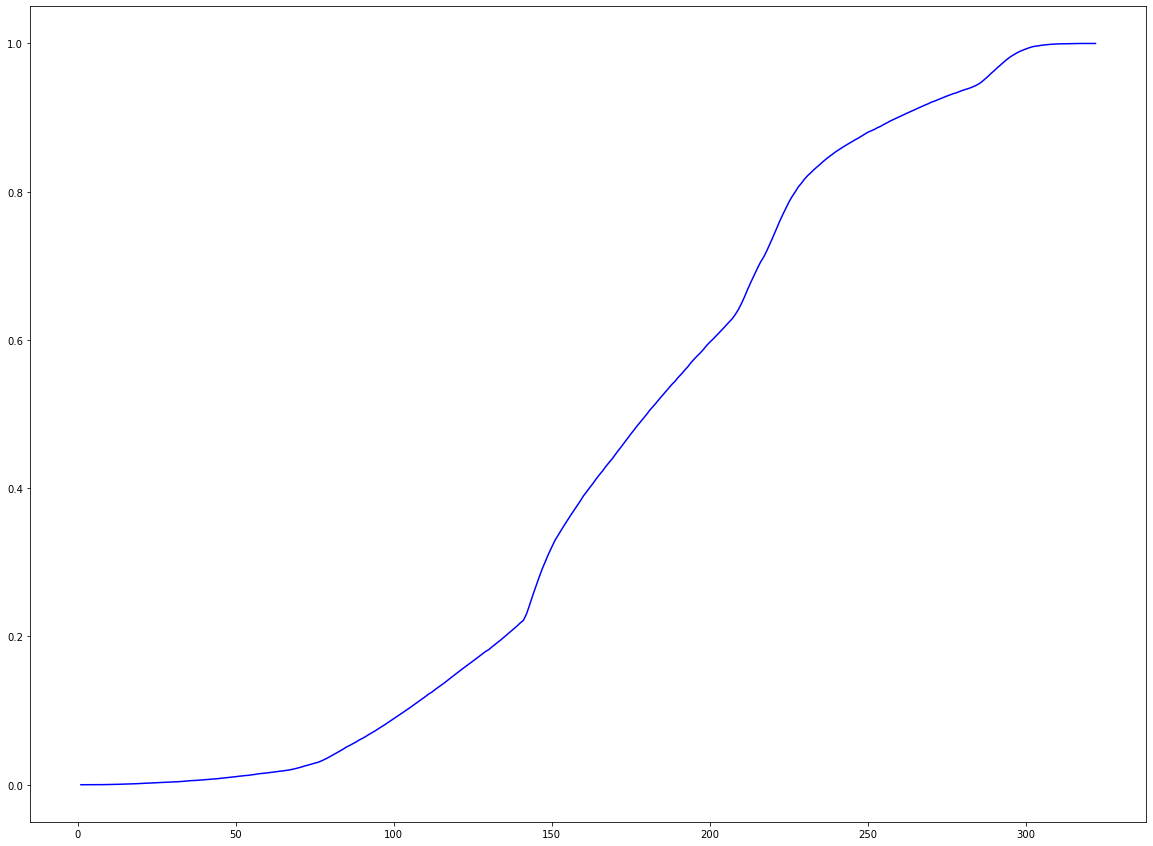

In [20]:
x=[]
y=[]
i = 1
prob = 0
while prob < 1:
    prob = len(sorted[sorted[0] <= i])/50000
    x.append(i)
    y.append(prob)
    i+=1
    

plt.figure(figsize=(20, 15))
plt.plot(x, y, color ='blue')

In [25]:
from scipy.signal import fftconvolve

In [53]:
hero_pdf = np.empty(len(hero_prob_arr))
hero_pdf[0] = hero_prob_arr[0]
for i in range(1, len(hero_prob_arr)):
    hero_pdf[i] = hero_prob_arr[i] - hero_prob_arr[i-1]
    

H2 = fftconvolve(hero_pdf, hero_pdf)
H = np.zeros(len(H2))
H[:len(hero_pdf)] = hero_pdf

hero_needed_dist = 0.5*H + 0.5*H2

weapon_pdf = np.empty(len(weapon_prob_arr))
weapon_pdf[0] = weapon_prob_arr[0]
for i in range(1, len(weapon_prob_arr)):
    weapon_pdf[i] = weapon_prob_arr[i] - weapon_prob_arr[i-1]
    

W2 = fftconvolve(weapon_pdf, weapon_pdf)
W1 = np.zeros(len(W2))
W1[:len(weapon_pdf)] = weapon_pdf

weapon_needed_dist = 0.375*W1 + 0.625*W2

In [55]:
def convolve_n(dist, n):
    out = dist
    for _ in range(n-1):
        out = fftconvolve(out, dist)
    return out

In [56]:
heroes = convolve_n(hero_needed_dist, 4)
weapons = convolve_n(weapon_needed_dist, 2)

total = fftconvolve(heroes, weapons)


In [61]:
luck = total[:540+1].sum()
luck

0.49660375343872803

In [58]:
total

array([ 6.72404519e-16,  4.04223979e-15,  1.41706605e-14, ...,
       -7.19588997e-19, -7.19588997e-19, -9.25185854e-19])

In [59]:
total.sum()

1.0